In [1]:
import scanpy as sc
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm 
import collections

adata = sc.read_h5ad('/home/kevin/storage_kevin/priscilla_MT/MDS_adata_for_publication_v2.h5ad')

HSPC_like = adata.obs['celltype_v2'].to_numpy()
HSPC_like[np.isin(adata.obs['celltype_v2'].to_numpy(), np.array(['HSC', 'GMP', 'MEP/MKP', 'MPP', 'MEP', 'Monocyte progenitor', 'BMCP', 'Erythroblast']))] = 'HSPC_like'
adata.obs['HSPC_like'] = HSPC_like

adata.obs['timepoint_celltype'] = adata.obs['timepoint_coarse'].astype(str) + '_' + adata.obs['celltype_v2'].astype(str)
adata.obs['timepoint_HSPC_like'] = adata.obs['timepoint_coarse'].astype(str) + '_' + adata.obs['HSPC_like'].astype(str)

adata.obs['HSPC_like'] = adata.obs['HSPC_like'].astype('category')
adata.obs['timepoint_celltype'] = adata.obs['timepoint_celltype'].astype('category')
adata.obs['timepoint_HSPC_like'] = adata.obs['timepoint_HSPC_like'].astype('category')

adata_subset = adata[adata.obs['patient_alias'] == 'P17']
adata_subset

View of AnnData object with n_obs × n_vars = 6016 × 28762
    obs: 'BARCODE', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'timepoint', 'disease_state', 'outcome_C12D29', 'outcome_C6D28', 'timepoint_coarse', 'leiden', 'patient_alias', 'SRSF2_p.Pro95Leu', 'SRSF2_p.Pro95Arg', 'SRSF2_p.Pro95His', 'TP53_p.Cys238Tyr', 'TP53_p.Pro177His', 'TP53_p.Ser106Arg', 'celltype_v2', 'SRSF2_p.Pro95His_updated', 'SRSF2_p.Pro95Leu_updated', 'SRSF2_p.Pro95Arg_updated', 'RUNX1_p.His105Gln_updated', 'NRAS_p.Gly12Asp_updated', 'RUNX1_p.Arg201Gln_updated', 'TP53_p.Cys238Tyr_updated', 'TP53_p.Pro177His_updated', 'new_dataset', 'HSPC_like', 'timepoint_celltype', 'timepoint_HSPC_like'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'chromosome', 'gene', 'start', 'end'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_cnv', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

         Falling back to preprocessing with `sc.pp.pca` and default params.


/ssd/users/kevin/conda/test_SNPmanifold/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/ssd/users/kevin/conda/test_SNPmanifold/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


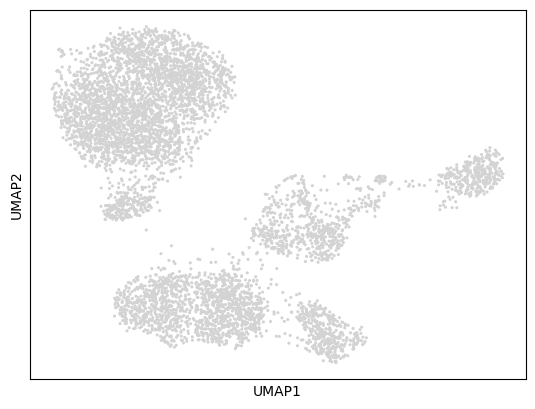

In [2]:
import anndata as ad

adata_subset_CNV = ad.AnnData(adata_subset.obsm['X_cnv'].toarray())
adata_subset_CNV.obs = adata_subset.obs

sc.pp.neighbors(adata_subset_CNV)
sc.tl.umap(adata_subset_CNV)
sc.pl.umap(adata_subset_CNV)

/ssd/users/kevin/conda/test_SNPmanifold/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


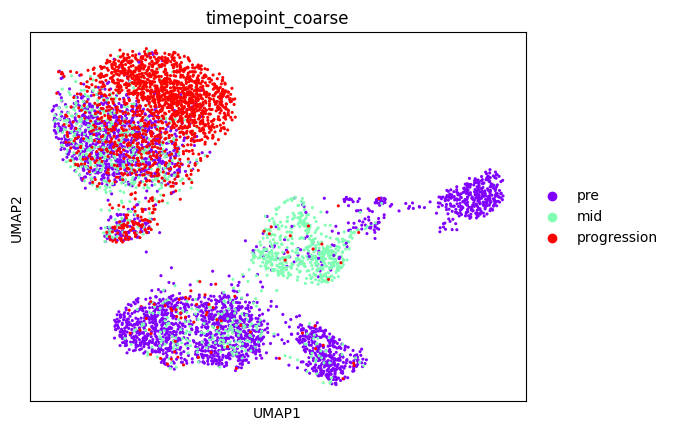

/ssd/users/kevin/conda/test_SNPmanifold/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


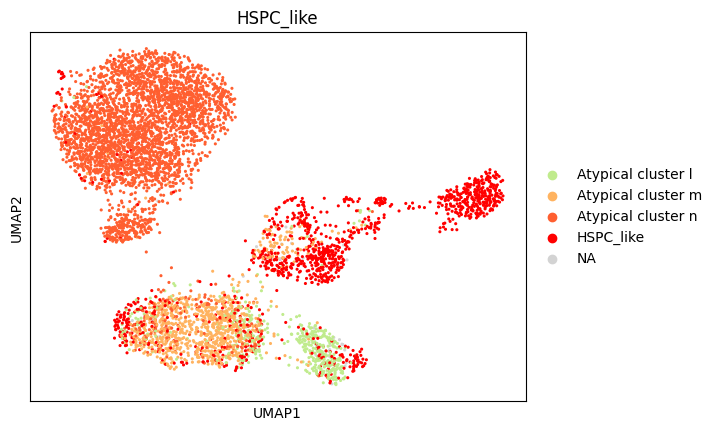

In [3]:
sc.pl.umap(adata_subset_CNV, color = 'timepoint_coarse', palette = 'rainbow')
sc.pl.umap(adata_subset_CNV, color = 'HSPC_like', groups = ['HSPC_like', 'Atypical cluster l', 'Atypical cluster m', 'Atypical cluster n'], palette = 'rainbow')

/ssd/users/kevin/conda/test_SNPmanifold/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


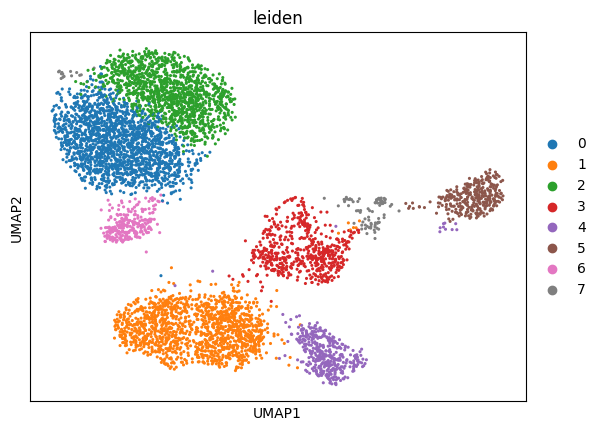

In [4]:
adata_subset_CNV.obs = adata_subset_CNV.obs.drop('leiden', axis=1)
sc.tl.leiden(adata_subset_CNV, resolution = 0.5)
sc.pl.umap(adata_subset_CNV, color = 'leiden')

leiden


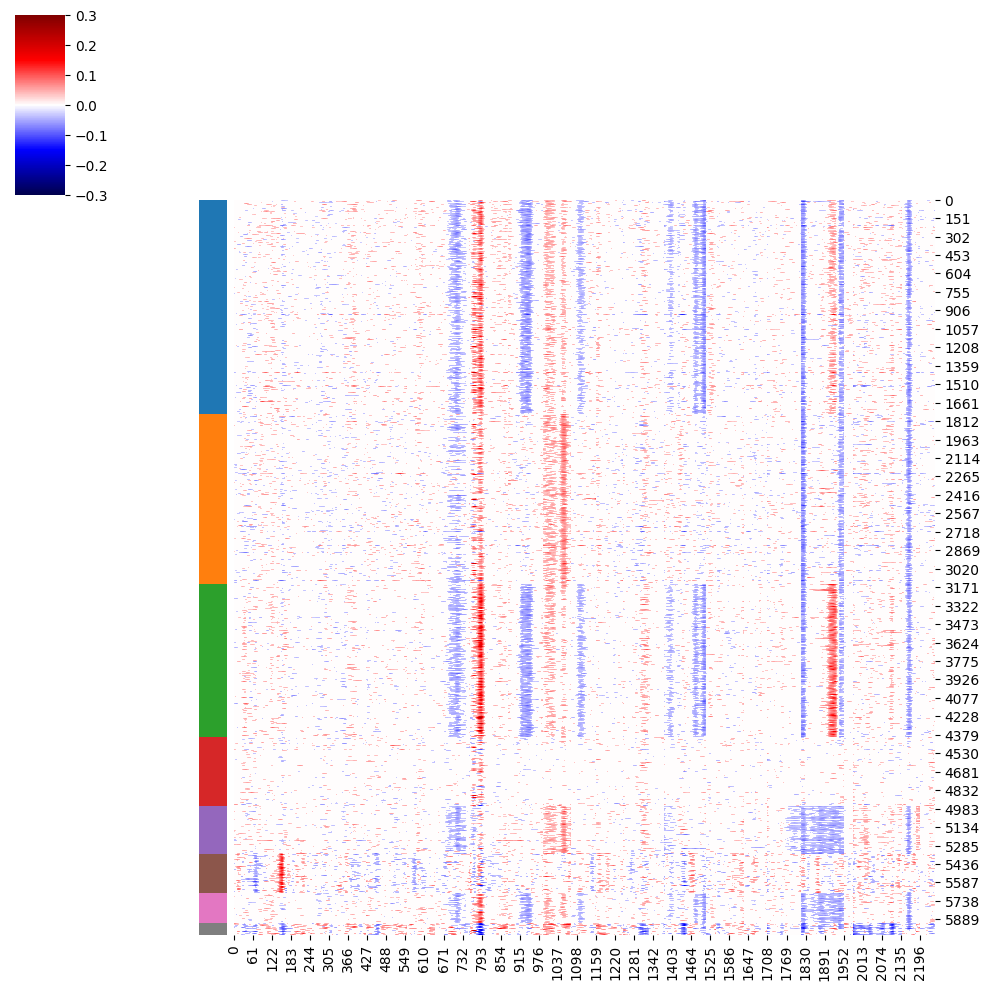

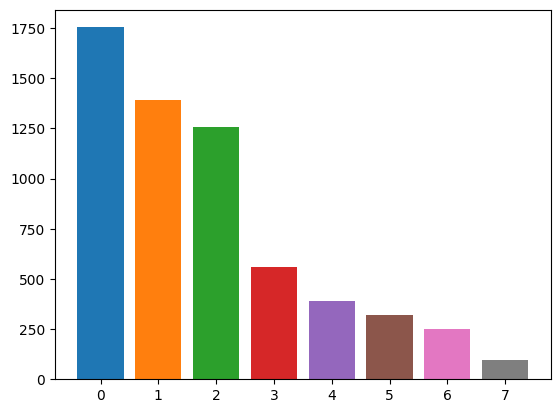

In [5]:
sorted_order = np.empty(0)

for k in ['1', '6', '0', '2', '4']:
    
    sorted_order = np.concatenate((sorted_order, np.where(adata_subset_CNV.obs['leiden'] == k)[0]))
    
sorted_order = sorted_order.astype(int)

adata_subset_CNV_sorted = adata_subset_CNV[sorted_order]

print('leiden')

CNV_cluster = pd.Series(adata_subset_CNV_sorted.obs['leiden'].astype(str)).map(dict(zip(adata_subset_CNV_sorted.obs['leiden'].cat.categories, cm.tab10(np.linspace(0, 1, 10))[0:len(adata_subset_CNV.obs['leiden'].cat.categories), :]))).to_numpy()

fig = sns.clustermap(adata_subset_CNV_sorted.X, col_cluster=False, row_cluster=False, center = 0, cmap = "seismic", row_colors = CNV_cluster, vmin = -0.3, vmax = 0.3)
plt.show()

plt.bar(adata_subset_CNV_sorted.obs['leiden'].cat.categories, list(collections.Counter(adata_subset_CNV_sorted.obs['leiden']).values()), color = cm.tab10(np.linspace(0, 1, 10))[0:len(adata_subset_CNV.obs['leiden'].cat.categories), :])
plt.show()

leiden


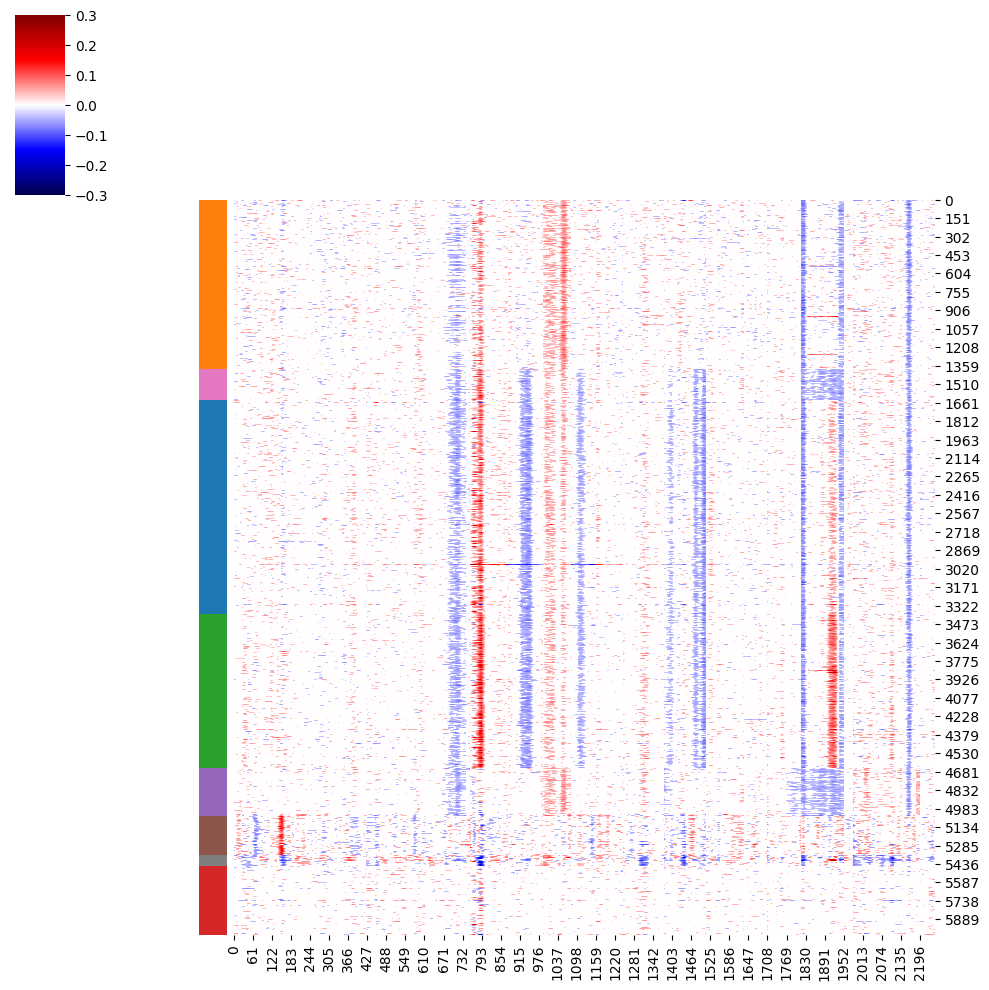

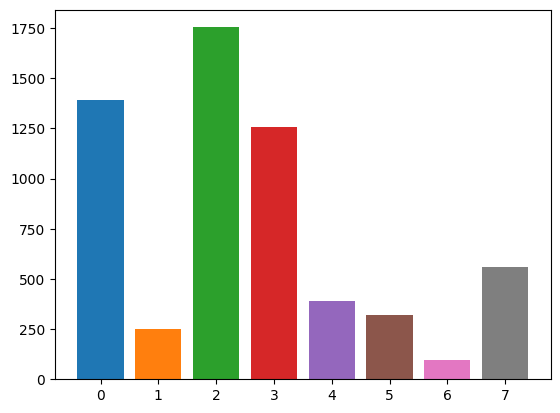

In [7]:
sorted_order = np.empty(0)

for k in ['1', '6', '0', '2', '4', '5', '7', '3']:
    
    sorted_order = np.concatenate((sorted_order, np.where(adata_subset_CNV.obs['leiden'] == k)[0]))
    
sorted_order = sorted_order.astype(int)

adata_subset_CNV_sorted = adata_subset_CNV[sorted_order]

print('leiden')

CNV_cluster = pd.Series(adata_subset_CNV_sorted.obs['leiden'].astype(str)).map(dict(zip(adata_subset_CNV_sorted.obs['leiden'].cat.categories, cm.tab10(np.linspace(0, 1, 10))[0:len(adata_subset_CNV.obs['leiden'].cat.categories), :]))).to_numpy()

fig = sns.clustermap(adata_subset_CNV_sorted.X, col_cluster=False, row_cluster=False, center = 0, cmap = "seismic", row_colors = CNV_cluster, vmin = -0.3, vmax = 0.3)
plt.show()

plt.bar(adata_subset_CNV_sorted.obs['leiden'].cat.categories, list(collections.Counter(adata_subset_CNV_sorted.obs['leiden']).values()), color = cm.tab10(np.linspace(0, 1, 10))[0:len(adata_subset_CNV.obs['leiden'].cat.categories), :])
plt.show()

leiden


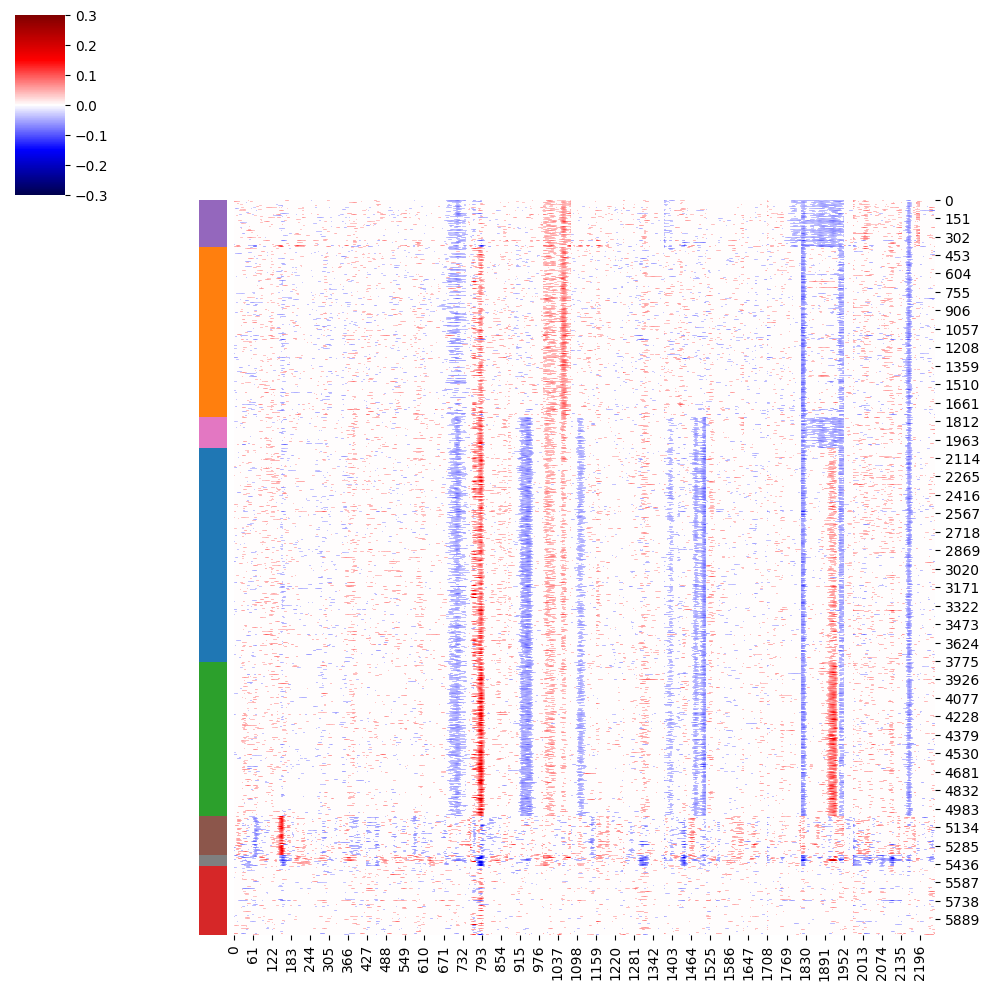

In [10]:
sorted_order = np.empty(0)

for k in ['4', '1', '6', '0', '2', '5', '7', '3']:
    
    sorted_order = np.concatenate((sorted_order, np.where(adata_subset_CNV.obs['leiden'] == k)[0]))
    
sorted_order = sorted_order.astype(int)

adata_subset_CNV_sorted = adata_subset_CNV[sorted_order]

print('leiden')

CNV_cluster = pd.Series(adata_subset_CNV_sorted.obs['leiden'].astype(str)).map(dict(zip(adata_subset_CNV_sorted.obs['leiden'].cat.categories, cm.tab10(np.linspace(0, 1, 10))[0:len(adata_subset_CNV.obs['leiden'].cat.categories), :]))).to_numpy()

fig = sns.clustermap(adata_subset_CNV_sorted.X, col_cluster=False, row_cluster=False, center = 0, cmap = "seismic", row_colors = CNV_cluster, vmin = -0.3, vmax = 0.3)
plt.show()

In [13]:
adata_subset_CNV.obs['leiden_RNA'] = adata[adata.obs['patient_alias'] == 'P17'].obs['leiden']

In [14]:
adata_subset_CNV.write_h5ad('P17_CNV.h5ad')

/tmp/ipykernel_892503/454705790.py:10: RuntimeWarning: invalid value encountered in true_divide
  AF_mquad = AD_mquad / DP_mquad


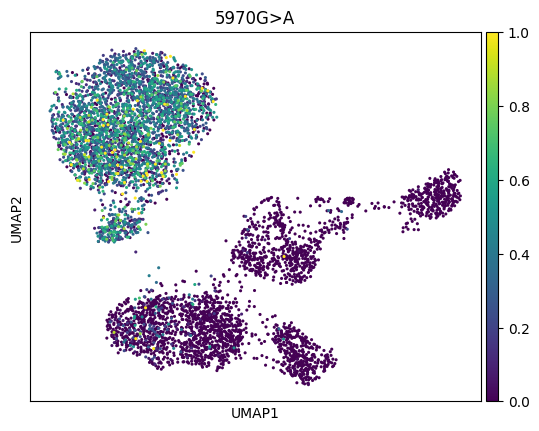

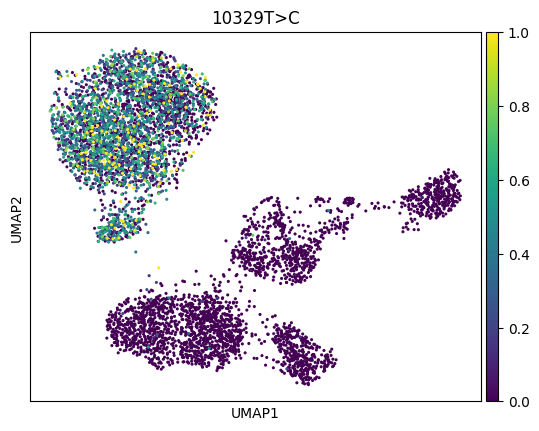

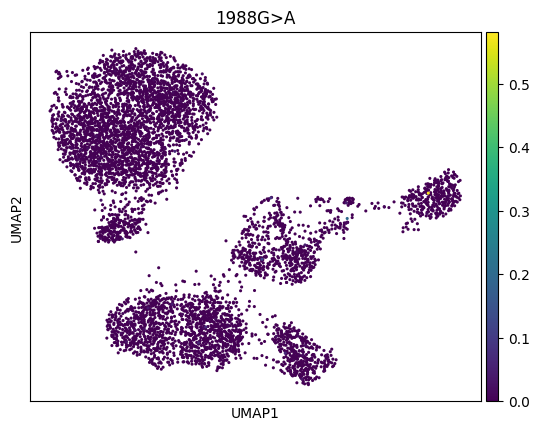

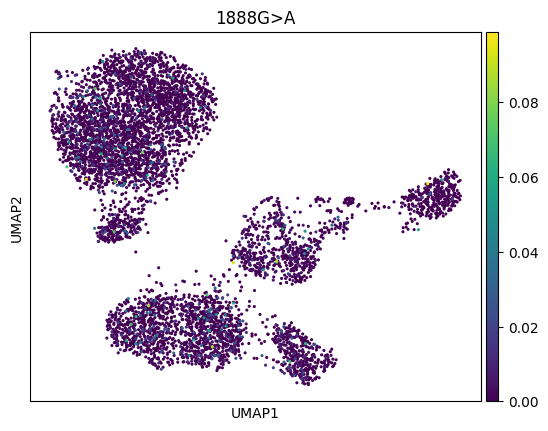

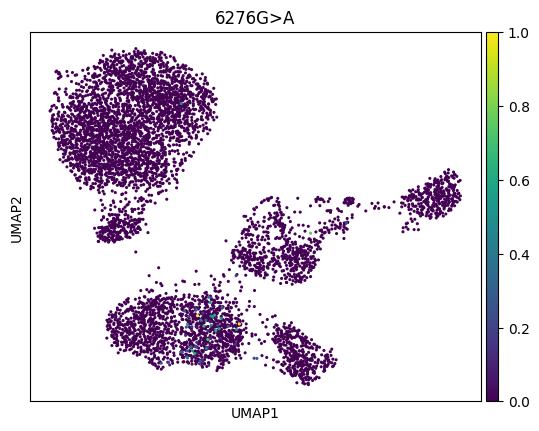

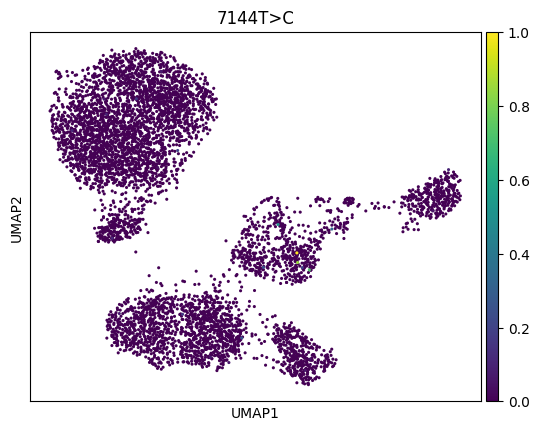

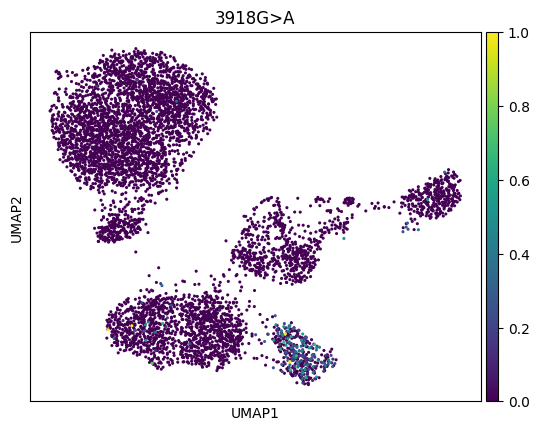

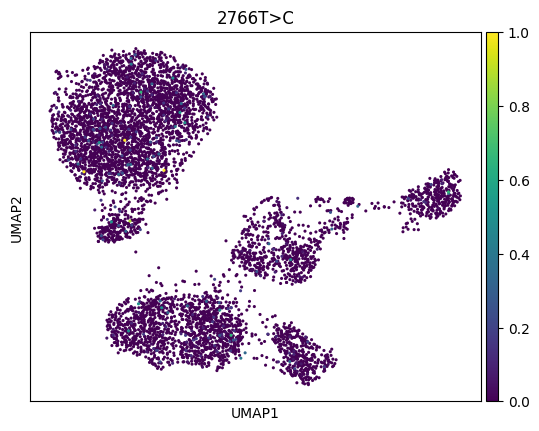

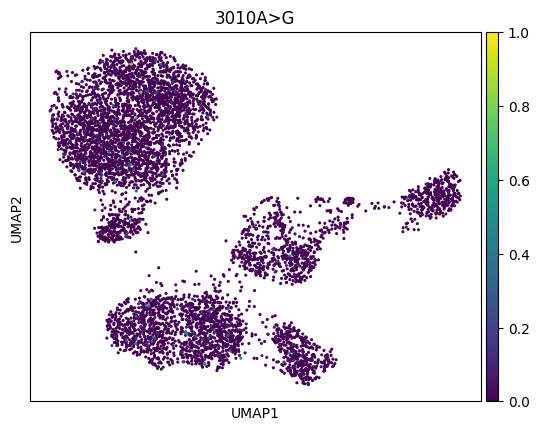

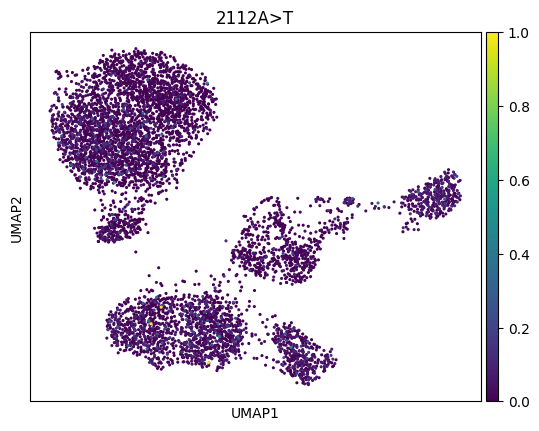

In [15]:
from scipy.sparse import coo_matrix
from scipy import io
import numpy as np
import pandas as pd

AD_mquad = io.mmread("/home/kevin/storage_kevin/priscilla_MT/P17_bamfiles/CSP_filtered_final_all/mquad/passed_ad.mtx").toarray()
DP_mquad = io.mmread("/home/kevin/storage_kevin/priscilla_MT/P17_bamfiles/CSP_filtered_final_all/mquad/passed_dp.mtx").toarray()
variant_name_mquad = pd.read_csv("/home/kevin/storage_kevin/priscilla_MT/P17_bamfiles/CSP_filtered_final_all/mquad/passed_variant_names.txt", sep = '\t', header = None)

AF_mquad = AD_mquad / DP_mquad
AF_mquad[np.isnan(AF_mquad)] = 0

for k in range(AF_mquad.shape[0]):
    
    adata_subset_CNV.obs[variant_name_mquad[0].iloc[k]] = AF_mquad.T[:, k]

for k in range(AF_mquad.shape[0]):
    
    sc.pl.umap(adata_subset_CNV, color = variant_name_mquad[0].iloc[k])

In [16]:
for k in range(AF_mquad.shape[0]):
    
    print(variant_name_mquad[0].iloc[k])
    print(collections.Counter(adata_subset_CNV[adata_subset_CNV.obs[variant_name_mquad[0].iloc[k]] > 0.5].obs['HSPC_like']))

5970G>A
Counter({'Atypical cluster n': 590, 'HSPC_like': 9, 'Atypical cluster m': 7, 'Atypical cluster l': 5})
10329T>C
Counter({'Atypical cluster n': 567, 'HSPC_like': 11})
1988G>A
Counter({'HSPC_like': 1})
1888G>A
Counter()
6276G>A
Counter({'Atypical cluster m': 9, 'HSPC_like': 1, 'Atypical cluster n': 1})
7144T>C
Counter({'HSPC_like': 3})
3918G>A
Counter({'Atypical cluster l': 10, 'Atypical cluster m': 2, 'HSPC_like': 2, 'Atypical cluster j': 1})
2766T>C
Counter({'Atypical cluster n': 5, 'Atypical cluster m': 1, 'HSPC_like': 1})
3010A>G
Counter({'Atypical cluster n': 2, 'HSPC_like': 1})
2112A>T
Counter({'Atypical cluster m': 2, 'Atypical cluster l': 1})
